In [1]:
import pandas as pd
import mat73
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums, sem
import seaborn as sns
from itertools import combinations


In [2]:
base_path = r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data"

subj = 'pdnm091'
condition1 = 'ONmed_ONstimDorsal'    # ses01
condition2 = 'OFFmed_ONstimDorsal'   # ses02
condition3 = 'OFFmed_ONstimVentral'  # ses03
condition4 = 'ONmed_OFFstim'         # ses04, split into block2 + block3
condition5 = 'OFFmed_OFFstim'        # ses05
condition6 = 'ONmed_ONstimVentral'   # ses06

mat_path1 = base_path + r"\Results_PDNM091_S1_C1_B2_2026-04-13.mat"
data1 = mat73.loadmat(mat_path1)

mat_path2 = base_path + r"\Results_PDNM091_S2_C2_B2_2026-04-27.mat"
data2 = mat73.loadmat(mat_path2)

mat_path3 = base_path + r"\Results_PDNM091_S3_C3_B2_2026-06-30.mat"
data3 = mat73.loadmat(mat_path3)

mat_path4_block2 = base_path + r"\Results_PDNM091_S4_C4_B2_2026-07-09.mat"
data4_block2 = mat73.loadmat(mat_path4_block2)

mat_path4_block3 = base_path + r"\Results_PDNM091_S4_C4_B3_2026-07-09.mat"
data4_block3 = mat73.loadmat(mat_path4_block3)

mat_path5 = base_path + r"\Results_PDNM091_S5_C5_B2_2026-07-23.mat"
data5 = mat73.loadmat(mat_path5)

mat_path6 = base_path + r"\Results_PDNM091_S6_C6_B2_2026-07-29.mat"
data6 = mat73.loadmat(mat_path6)


In [3]:

manifest_ses01 = pd.read_csv(base_path + r"\PDNM091_session_1.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses02 = pd.read_csv(base_path + r"\PDNM091_session_2.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses03 = pd.read_csv(base_path + r"\PDNM091_session_3.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses04_block2 = pd.read_csv(base_path + r"\PDNM091_session_4_block2.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses04_block3 = pd.read_csv(base_path + r"\PDNM091_session_4_block3.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses05 = pd.read_csv(base_path + r"\PDNM091_session_5.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses06 = pd.read_csv(base_path + r"\PDNM091_session_6.csv").dropna(subset=['trial']).reset_index(drop=True)

In [4]:
# Session 4, Block 2
results_pdnm091_ses04_block2 = data4_block2['Results']  # adjust key name if needed
trials_pdnm091_ses04_block2 = pd.DataFrame(results_pdnm091_ses04_block2['Trials'])

# Session 4, Block 3
results_pdnm091_ses04_block3 = data4_block3['Results']  # adjust key name if needed
trials_pdnm091_ses04_block3 = pd.DataFrame(results_pdnm091_ses04_block3['Trials'])


# --- Manifests ---
trial_offset_manifest = len(manifest_ses04_block2)
manifest_ses04_block3['trial'] = manifest_ses04_block3['trial'] + trial_offset_manifest

manifest_ses04 = pd.concat([manifest_ses04_block2, manifest_ses04_block3], ignore_index=True)

# --- Trials (from .mat Results) ---
imageindex_offset_trials = len(trials_pdnm091_ses04_block2)
trials_pdnm091_ses04_block3['ImageIndex'] = trials_pdnm091_ses04_block3['ImageIndex'] + imageindex_offset_trials

trials_pdnm091_ses04 = pd.concat([trials_pdnm091_ses04_block2, trials_pdnm091_ses04_block3], ignore_index=True)

# sanity check
print(manifest_ses04.iloc[trial_offset_manifest-1 : trial_offset_manifest+1])
print(trials_pdnm091_ses04.iloc[imageindex_offset_trials-1 : imageindex_offset_trials+1])

    trial             ID           filename Category  Valence val_bin  \
55   56.0  Objects_235_h  Objects_235_h.jpg  Objects     3.96   4-Mar   
56   57.0  Objects_184_v  Objects_184_v.jpg  Objects     4.18   5-Apr   

   condition  
55      TONE  
56      FEEL  
   Condition      CueText ImageIndex           RT_Valence Valence
55      TONE    Tone down       56.0   1.0682418999967922     3.0
56      FEEL  Feel freely       57.0  0.35592860000178916     2.0


In [5]:
# Session 1
results_pdnm091_ses01 = data1['Results']  # adjust key name if needed
trials_pdnm091_ses01 = pd.DataFrame(results_pdnm091_ses01['Trials'])
trials_pdnm091_ses01['ImageIndex'] = trials_pdnm091_ses01['ImageIndex'].astype(int)
merged_df_ses01 = pd.merge(trials_pdnm091_ses01, manifest_ses01, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses01.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses01.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses01 = merged_df_ses01.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})

# Session 2
results_pdnm091_ses02 = data2['Results']  # adjust key name if needed
trials_pdnm091_ses02 = pd.DataFrame(results_pdnm091_ses02['Trials'])
trials_pdnm091_ses02['ImageIndex'] = trials_pdnm091_ses02['ImageIndex'].astype(int)
merged_df_ses02 = pd.merge(trials_pdnm091_ses02, manifest_ses02, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses02.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses02.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses02 = merged_df_ses02.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})

# Session 3
results_pdnm091_ses03 = data3['Results']  # adjust key name if needed
trials_pdnm091_ses03 = pd.DataFrame(results_pdnm091_ses03['Trials'])
trials_pdnm091_ses03['ImageIndex'] = trials_pdnm091_ses03['ImageIndex'].astype(int)
merged_df_ses03 = pd.merge(trials_pdnm091_ses03, manifest_ses03, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses03.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses03.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses03 = merged_df_ses03.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'ImageIndex': 'TrialNumber',
    'Condition': 'instruction'
})

# Session 4 (uses the concatenated trials_pdnm091_ses04 / manifest_ses04)
trials_pdnm091_ses04['ImageIndex'] = trials_pdnm091_ses04['ImageIndex'].astype(int)
merged_df_ses04 = pd.merge(trials_pdnm091_ses04, manifest_ses04, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses04.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses04.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses04 = merged_df_ses04.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})

# Session 5
results_pdnm091_ses05 = data5['Results']  # adjust key name if needed
trials_pdnm091_ses05 = pd.DataFrame(results_pdnm091_ses05['Trials'])
trials_pdnm091_ses05['ImageIndex'] = trials_pdnm091_ses05['ImageIndex'].astype(int)
merged_df_ses05 = pd.merge(trials_pdnm091_ses05, manifest_ses05, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses05.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses05.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses05 = merged_df_ses05.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})

# Session 6
results_pdnm091_ses06 = data6['Results']  # adjust key name if needed
trials_pdnm091_ses06 = pd.DataFrame(results_pdnm091_ses06['Trials'])
trials_pdnm091_ses06['ImageIndex'] = trials_pdnm091_ses06['ImageIndex'].astype(int)
merged_df_ses06 = pd.merge(trials_pdnm091_ses06, manifest_ses06, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses06.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses06.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses06 = merged_df_ses06.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})

In [6]:
def plot_valence_vs_normative(merged_df, condition, subj, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    normative_ratings = merged_df['normative_rating'].values
    valence_ratings = merged_df['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)

    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    num_valence_nans = np.isnan(valence_ratings).sum()
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7)

    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)

    ax.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label='Linear fit')
    ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
    ax.legend(loc='upper left', bbox_to_anchor=(0, 1))
    ax.set_xlabel('Normative Ratings')
    ax.set_ylabel('Valence Ratings')
    ax.set_title(f'{condition} {subj} Valence Ratings')
    ax.set_xticks(np.arange(1, 10, 1))
    ax.set_yticks(np.arange(1, 10, 1))
    ax.set_xlim(1, 9)
    ax.set_ylim(0, 10)
    #ax.text(0.75, 0.15, f'Number of NaNs: {num_valence_nans}', fontsize=10, color='red', transform=ax.transAxes)
    #num_trials = len(merged_df)
    #ax.text(0.75, 0.15, f'Number of Trials: {num_trials}', fontsize=10, color='red', transform=ax.transAxes)
    ax.grid(True)

    return ax

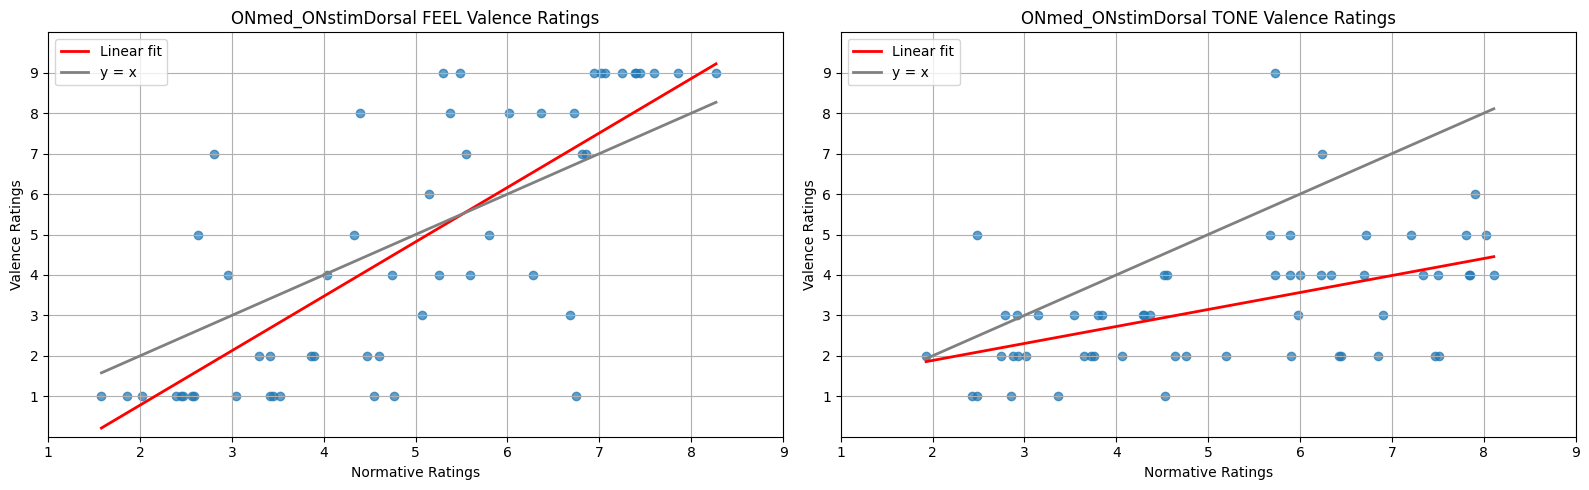

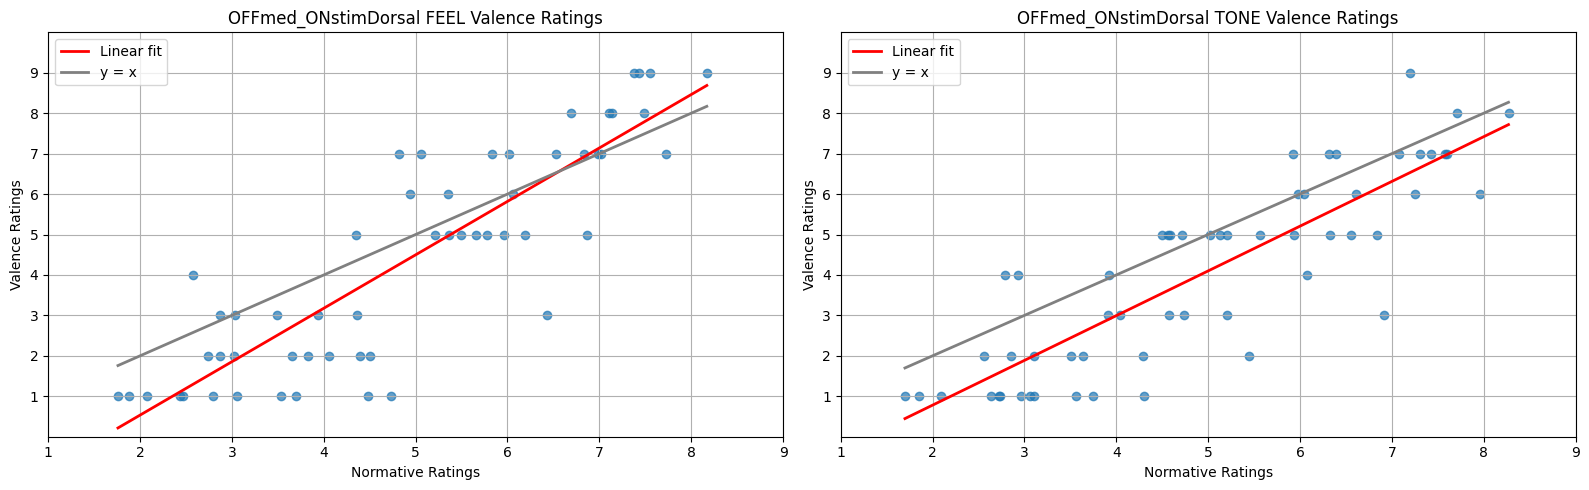

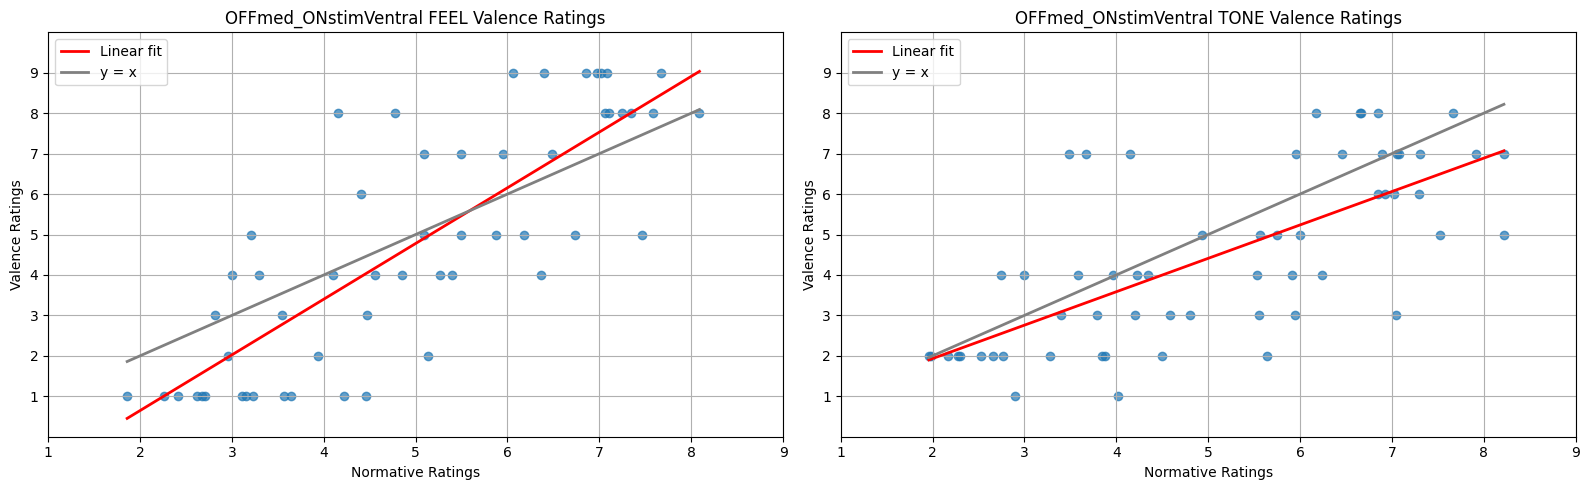

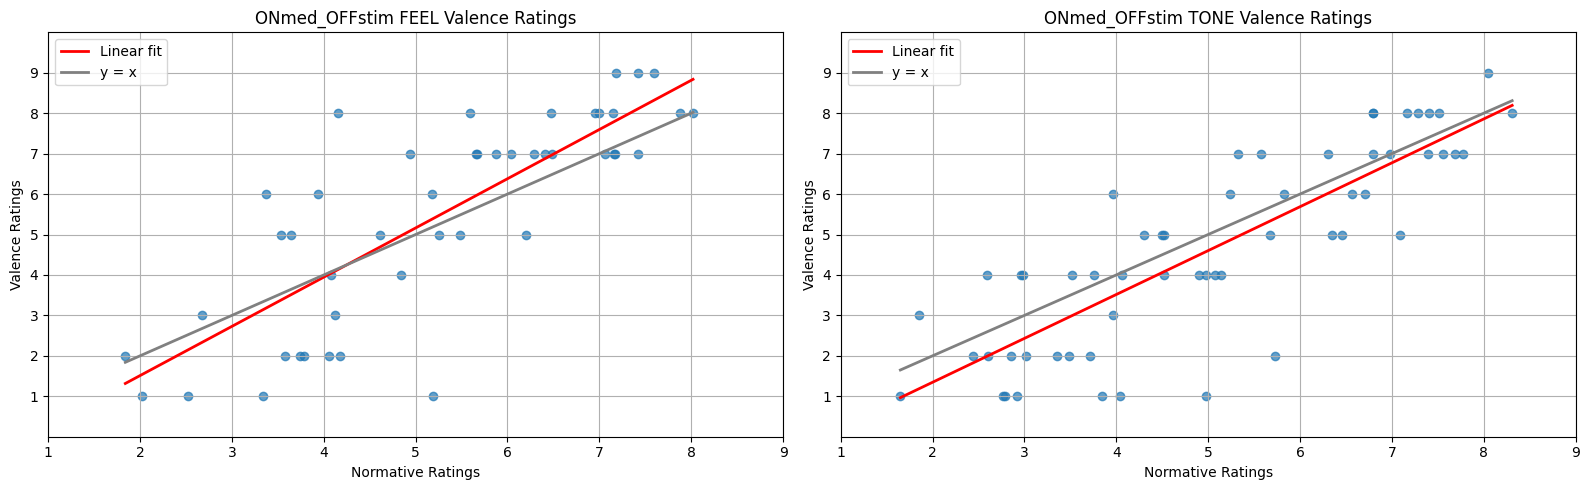

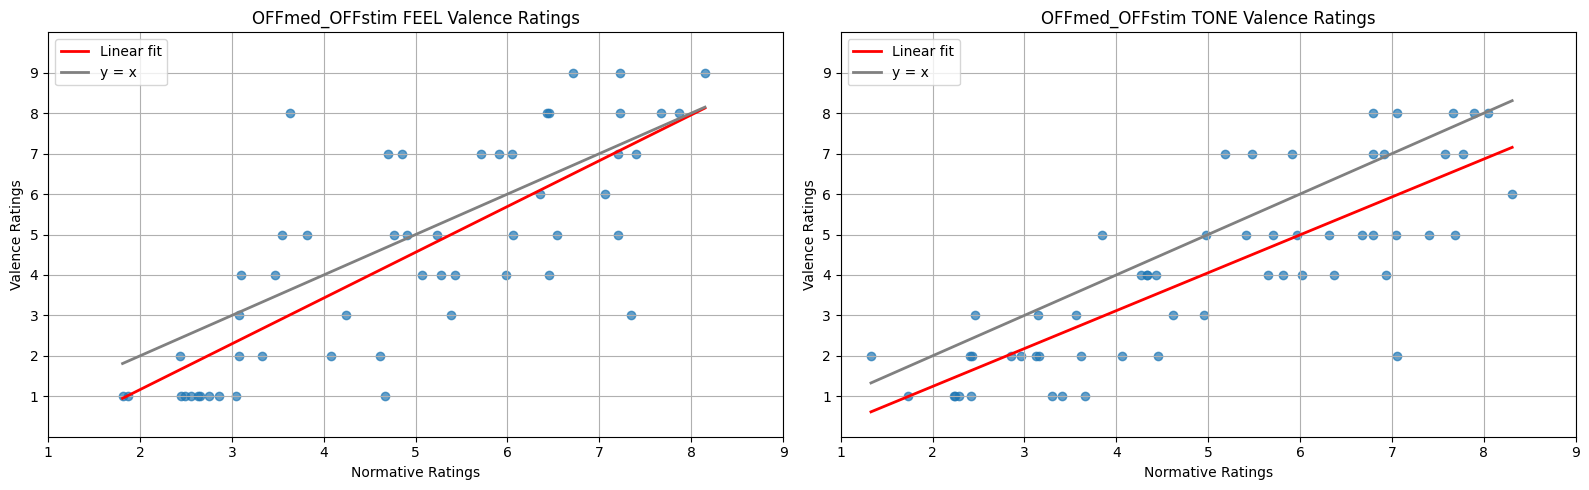

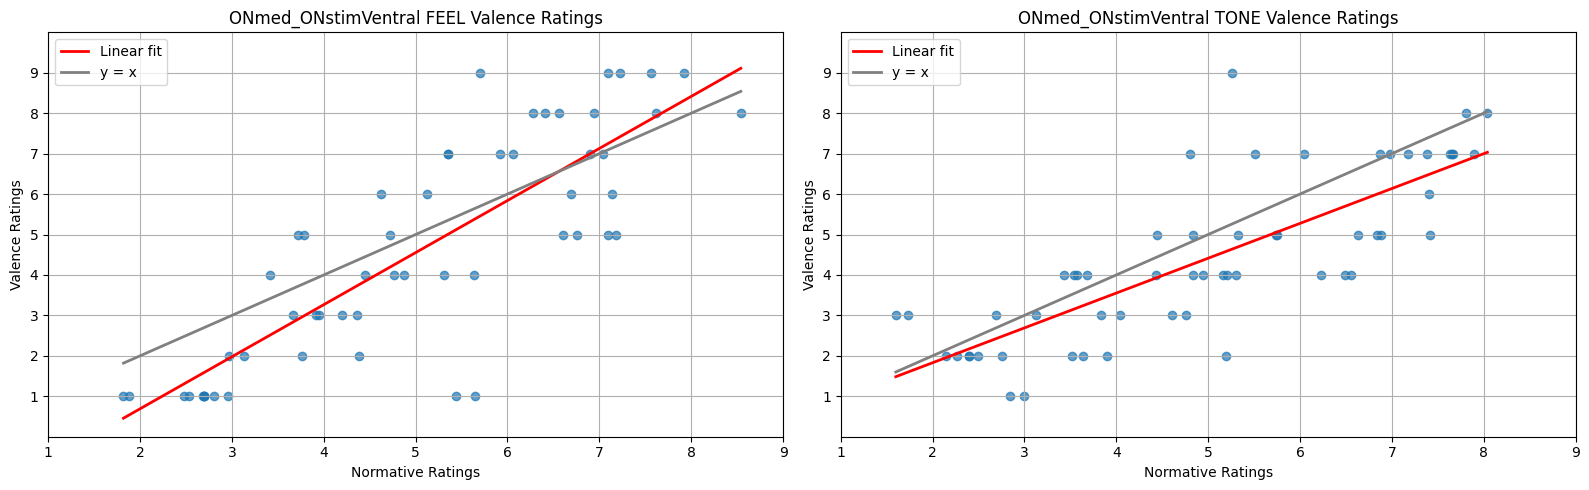

In [7]:
sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
    (condition4, merged_df_ses04),
    (condition5, merged_df_ses05),
    (condition6, merged_df_ses06),
]

for sess_label, df in sessions:
    feel_trials = df[df['instruction'] == 'FEEL']
    tone_trials = df[df['instruction'] == 'TONE']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_valence_vs_normative(feel_trials, sess_label, 'FEEL', ax=axes[0])
    plot_valence_vs_normative(tone_trials, sess_label, 'TONE', ax=axes[1])
    plt.tight_layout()
    plt.show()

In [8]:
cue_types = {'FEEL', 'TONE'}
cue_types = list({'FEEL', 'TONE'})
print(cue_types[0])
print(cue_types[1])

TONE
FEEL


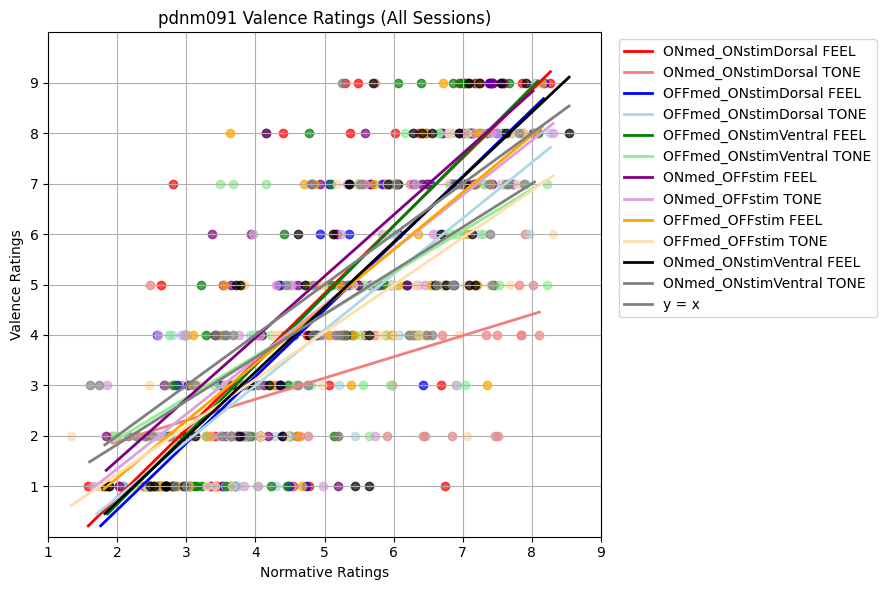

In [9]:
# Config: session dataframes, labels, and color pairs (feel color, tone color)
session_dfs = [merged_df_ses01, merged_df_ses02, merged_df_ses03, merged_df_ses04, merged_df_ses05, merged_df_ses06]
condition_labels = [condition1, condition2, condition3, condition4, condition5, condition6]
session_colors = [
    ('red', 'lightcoral'),
    ('blue', 'lightblue'),
    ('green', 'lightgreen'),
    ('purple', 'plum'),
    ('orange', 'navajowhite'),
    ('black', 'gray'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for i in range(len(session_dfs)):
    merged_df = session_dfs[i]
    condition_label = condition_labels[i]
    feel_color, tone_color = session_colors[i]

    feel_trials = merged_df[merged_df['instruction'] == cue_types[1]]
    tone_trials = merged_df[merged_df['instruction'] == cue_types[0]]

    # Feel trials
    normative_ratings = feel_trials['normative_rating'].values
    valence_ratings = feel_trials['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)
    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    # Tone trials
    tone_normative_ratings = tone_trials['normative_rating'].values
    tone_valence_ratings = tone_trials['participant_rating'].values
    tone_normative_ratings = pd.to_numeric(pd.Series(tone_normative_ratings), errors='coerce').to_numpy(dtype=float)
    tone_valence_ratings = pd.to_numeric(pd.Series(tone_valence_ratings), errors='coerce').to_numpy(dtype=float)
    tone_mask = ~np.isnan(tone_normative_ratings) & ~np.isnan(tone_valence_ratings)
    tone_norm_vals_clean = tone_normative_ratings[tone_mask]
    tone_valence_clean = tone_valence_ratings[tone_mask]

    # Feel
    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7, color=feel_color)
    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)
    ax.plot(x_fit, fit_fn(x_fit), color=feel_color, linewidth=2, label=f'{condition_label} {cue_types[1]}')

    # Tone
    ax.scatter(tone_norm_vals_clean, tone_valence_clean, alpha=0.7, color=tone_color)
    tone_coeffs = np.polyfit(tone_norm_vals_clean, tone_valence_clean, 1)
    tone_fit_fn = np.poly1d(tone_coeffs)
    tone_x_fit = np.linspace(tone_norm_vals_clean.min(), tone_norm_vals_clean.max(), 100)
    ax.plot(tone_x_fit, tone_fit_fn(tone_x_fit), color=tone_color, linewidth=2, label=f'{condition_label} {cue_types[0]}')

ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlabel('Normative Ratings')
ax.set_ylabel('Valence Ratings')
ax.set_title(f'{subj} Valence Ratings (All Sessions)')
ax.set_xticks(np.arange(1, 10, 1))
ax.set_yticks(np.arange(1, 10, 1))
ax.set_xlim(1, 9)
ax.set_ylim(0, 10)
ax.grid(True)

plt.tight_layout()

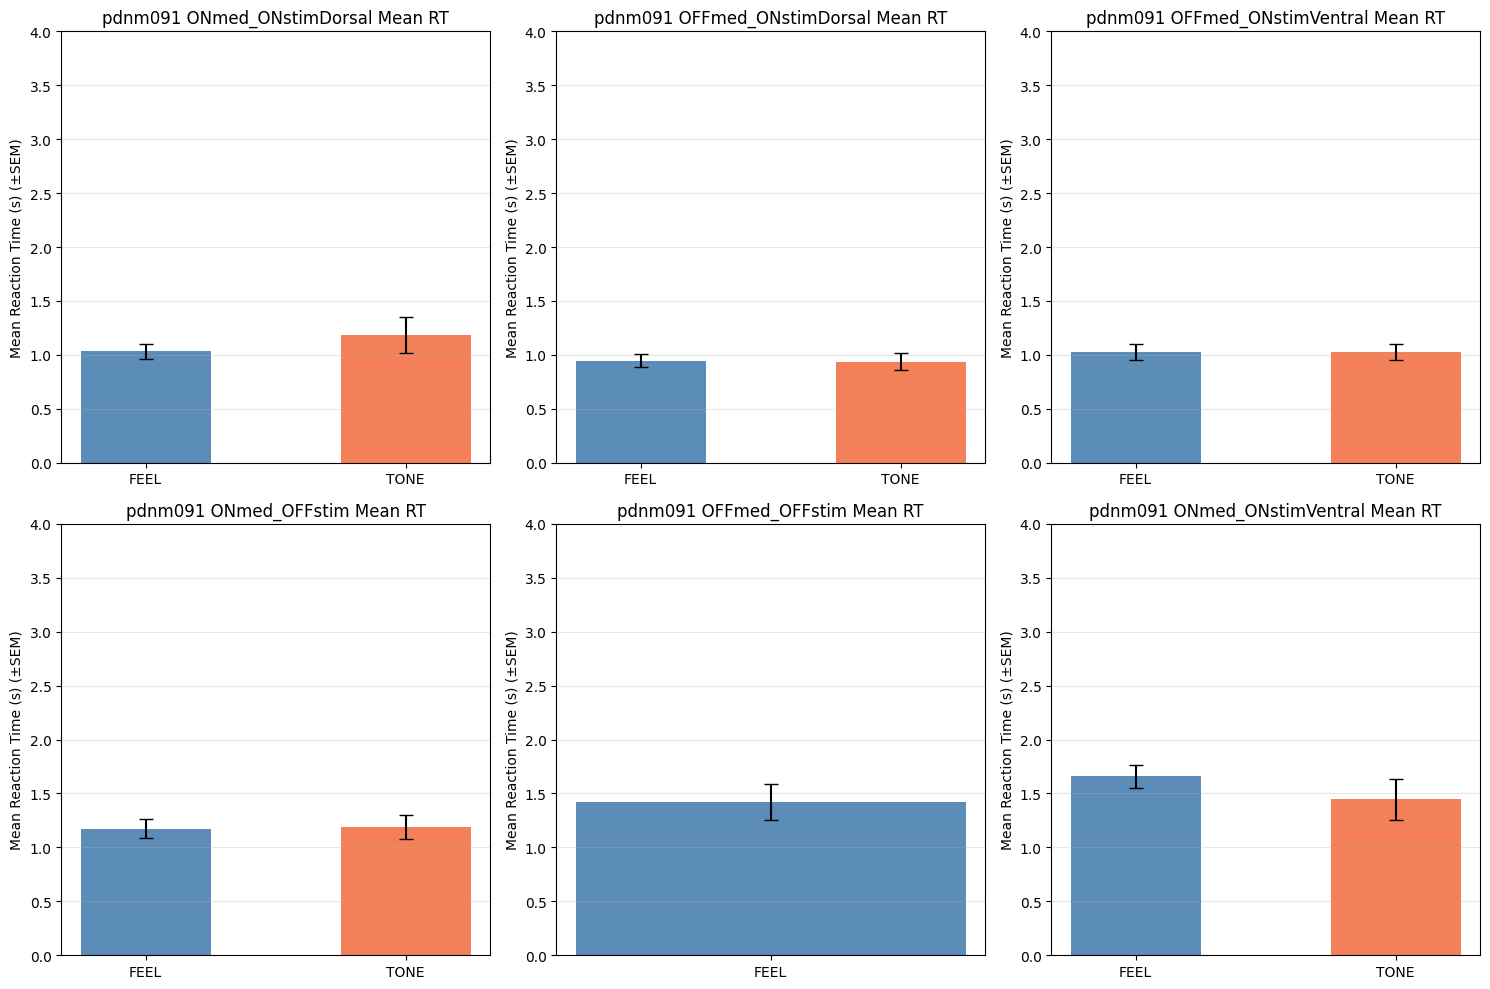

In [10]:
# plot mean +- sem reaction times for all feel and tone trials for all 6 sessions
mean_rt_feel_ses01 = merged_df_ses01[merged_df_ses01['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses01 = merged_df_ses01[merged_df_ses01['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses02 = merged_df_ses02[merged_df_ses02['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses02 = merged_df_ses02[merged_df_ses02['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses03 = merged_df_ses03[merged_df_ses03['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses03 = merged_df_ses03[merged_df_ses03['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses04 = merged_df_ses04[merged_df_ses04['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses04 = merged_df_ses04[merged_df_ses04['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses05 = merged_df_ses05[merged_df_ses05['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses05 = merged_df_ses05[merged_df_ses05['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses06 = merged_df_ses06[merged_df_ses06['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses06 = merged_df_ses06[merged_df_ses06['instruction'] == 'TONE']['RT_Valence'].mean()


def plot_rt_bar(merged_df, sess_label, ax):
    feel_rt = merged_df[merged_df['instruction'] == 'FEEL']['RT_Valence'].dropna()
    tone_rt = merged_df[merged_df['instruction'] == 'TONE']['RT_Valence'].dropna()

    means = [feel_rt.mean(), tone_rt.mean()]
    sems = [sem(feel_rt), sem(tone_rt)]

    ax.bar(['FEEL', 'TONE'], means, yerr=sems, capsize=5,
           color=['#5b8db8', '#f4805a'], width=0.5)

    ax.set_ylim(0, 4)
    ax.set_title(f'{subj} {sess_label} Mean RT')
    ax.set_ylabel('Mean Reaction Time (s) (±SEM)')
    ax.grid(True, axis='y', alpha=0.3)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
    (condition4, merged_df_ses04),
    (condition5, merged_df_ses05),
    (condition6, merged_df_ses06),
]

for (sess_label, df), ax in zip(sessions, axes):
    plot_rt_bar(df, sess_label, ax)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Confirm: look at the actual Python types in the TONE RT_Valence column
tone_ses05 = merged_df_ses05[merged_df_ses05['instruction'] == 'TONE']
for v in tone_ses05['RT_Valence']:
    if not isinstance(v, float):
        print(type(v), v)

<class 'numpy.ndarray'> 0.2916046001482755
<class 'numpy.ndarray'> 0.3919186999555677
<class 'numpy.ndarray'> 1.3723996998742223
<class 'numpy.ndarray'> 1.0427933000028133
<class 'numpy.ndarray'> 0.4531296999193728
<class 'numpy.ndarray'> 1.205246599856764
<class 'numpy.ndarray'> 0.6807172000408173
<class 'numpy.ndarray'> 0.9341548001393676
<class 'numpy.ndarray'> 0.9767994999419898
<class 'numpy.ndarray'> 1.4368481000419706
<class 'numpy.ndarray'> 1.8695218998473138
<class 'numpy.ndarray'> 0.4217674999963492
<class 'numpy.ndarray'> 1.2670106999576092
<class 'numpy.ndarray'> 0.45048519992269576
<class 'numpy.ndarray'> 0.9483374999836087
<class 'numpy.ndarray'> 1.601328699849546
<class 'numpy.ndarray'> 2.065066299866885
<class 'numpy.ndarray'> nan
<class 'numpy.ndarray'> 1.7942800999153405
<class 'numpy.ndarray'> 1.484472399810329
<class 'numpy.ndarray'> 0.3853658000007272
<class 'numpy.ndarray'> 7.92001374065876e-05
<class 'numpy.ndarray'> 1.2195909000001848
<class 'numpy.ndarray'> 1.0